# Drogued drifter in synthetic sheared flow

We test the `DroguedDrifter` with a simple, analytically defined velocity
profile: uniform flow at the surface, weaker (or reversed) flow at drogue depth.
This lets us verify the drifter behaviour without any external data dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from drogued_drifters import DroguedDrifter
from drogued_drifters.drifter import (
    drogue_added_mass,
    buoy_added_mass,
    drogue_drag_coeff,
    buoy_drag_coeff,
)

## Define a synthetic velocity profile

Surface current is 2 m/s due east. With depth, the current decays exponentially
(e-folding scale 1.5 m) and rotates clockwise at 45° per e-folding depth —
loosely resembling an Ekman-like spiral. At the full pole length (3 m = 2 e-folding
depths), the current has rotated 90° and decayed to ~14% of its surface value.
During the initial adjustment, the drogue swings through different depths,
sampling the full velocity profile.

In [2]:
def sheared_uv(*, t, z_d, y_b, x_b):
    """Eastward surface current with Ekman-like decay and rotation."""
    speed = 2.0
    decay = 1.5  # e-folding depth [m]
    rotation = 45  # degrees clockwise per e-folding depth

    angle = -np.radians(rotation) * z_d / decay
    factor = np.exp(-z_d / decay)

    U_b, V_b = speed, 0.0
    U_d = speed * factor * np.cos(angle)
    V_d = speed * factor * np.sin(angle)
    return U_b, V_b, U_d, V_d

## Physical parameters

Drifter geometry based on Callies et al.: drogue is a cross of two 0.5 m x 0.5 m
aluminium plates, buoy is a cylinder (diameter 0.1 m, submerged height 0.24 m),
connected by a 3 m pole.

In [3]:
rho = 1025.0  # sea water density [kg/m^3]

# drogue: cross of two plates
w_d, h_d, t_d = 0.5, 0.5, 0.002  # width, height, thickness [m]
rho_d = 2700.0  # aluminium density [kg/m^3]
m_d = 2 * rho_d * w_d * h_d * t_d  # two plates
m_hat_d = 2 * rho * w_d * h_d * t_d  # displaced water mass

# buoy: cylinder
d_b, h_b = 0.1, 0.24  # diameter, submerged height [m]
m_b = 1.0  # kg

drifter_params = dict(
    m_b=m_b,
    m_d=m_d,
    m_hat_d=m_hat_d,
    m_tilde_d=drogue_added_mass(rho=rho, w_d=w_d, h_d=h_d),
    m_tilde_b=buoy_added_mass(rho=rho, d_b=d_b, h_b=h_b),
    l=3.0,
    k_b=buoy_drag_coeff(rho=rho, d_b=d_b, h_b=h_b),
    k_d=drogue_drag_coeff(rho=rho, w_d=w_d, h_d=h_d),
)

## Set up two drifters

We compare a **complete drifter** against a **buoy-only** drifter (negligible
drogue mass, drag, and added mass). The buoy-only case should simply follow the
surface current.

In [4]:
drifter_complete = DroguedDrifter(**drifter_params, get_uv=sheared_uv)

buoy_only_params = {
    **drifter_params,
    "m_d": 0.01,
    "m_hat_d": 0.0,
    "m_tilde_d": 0.0,
    "k_d": 0.01,
}
drifter_buoy = DroguedDrifter(**buoy_only_params, get_uv=sheared_uv)

In [5]:
T = 40.0
dt = 1 / 3
t_eval = np.linspace(0, T, int(T / dt) + 1)

In [6]:
ds_complete = drifter_complete.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)
ds_buoy = drifter_buoy.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)

ds_complete

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 121)
Coordinates:
  * time     (time) float64 968B 0.0 0.3333 0.6667 1.0 ... 39.0 39.33 39.67 40.0
Data variables:
    x        (time) float64 968B 0.0 0.3768 1.18 2.072 ... 30.55 30.79 31.03
    y        (time) float64 968B 0.0 -0.0001715 -0.003466 ... -13.55 -13.68
    theta    (time) float64 968B 2.356 2.519 2.82 3.113 ... 2.213 2.213 2.213
    phi      (time) float64 968B 0.0 -0.007981 -0.04369 ... -2.853 -2.853 -2.853
    xd       (time) float64 968B 0.0 1.898 2.726 2.54 ... 0.7182 0.719 0.7186
    yd       (time) float64 968B 0.0 -0.002498 -0.01906 ... -0.3821 -0.3807
    thetad   (time) float64 968B 0.0 0.7721 0.959 ... -1.78e-05 -1.358e-05
    phid     (time) float64 968B 0.0 -0.05011 -0.2161 ... -0.0007849 -0.0001782

## Trajectories

The buoy-only drifter follows the surface current. The complete drifter is
slowed down by the drogue experiencing weaker flow at depth.

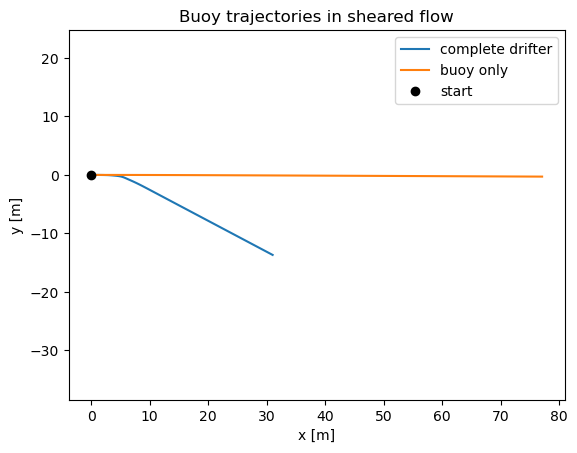

In [7]:
plt.plot(ds_complete.x, ds_complete.y, label="complete drifter")
plt.plot(ds_buoy.x, ds_buoy.y, label="buoy only")
plt.plot(0, 0, "ko", label="start")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Buoy trajectories in sheared flow")
plt.show()

## Pole angle over time

The pole angle `theta` should settle from its initial value (135°) to a
steady state near 180° (drogue hanging below the buoy, slightly deflected
by shear).

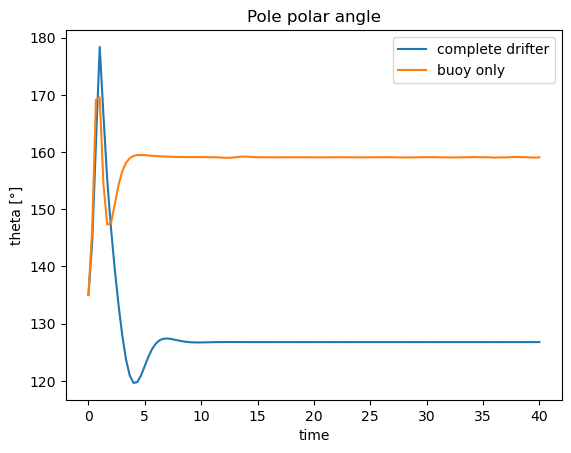

In [8]:
(ds_complete.theta * 180 / np.pi).plot(label="complete drifter")
(ds_buoy.theta * 180 / np.pi).plot(label="buoy only")
plt.ylabel("theta [°]")
plt.legend()
plt.title("Pole polar angle")
plt.show()

## Manuscript figure: buoy and drogue trajectories

Three-panel view: x-y (top), x-z (middle), y-z (bottom). Red lines show the
pole connecting buoy and drogue. A passive surface particle is shown for
reference in the x-y panel.

In [9]:
# finer time resolution for the figure
ds_fig = drifter_complete.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=np.arange(0, T + 0.1, 0.1),
)

In [10]:
# compute drogue position from buoy position + pole angles
l = drifter_params["l"]
x_d = ds_fig.x + l * np.sin(ds_fig.theta) * np.cos(ds_fig.phi)
y_d = ds_fig.y + l * np.sin(ds_fig.theta) * np.sin(ds_fig.phi)
z_d = l * np.cos(ds_fig.theta)

# passive surface particle: integrates surface velocity
t = ds_fig.time.values
dt_arr = np.diff(t, prepend=t[0])
U_b, V_b = 2.0, 0.0  # surface velocity from sheared_uv
x_particle = np.cumsum(U_b * dt_arr)
y_particle = np.cumsum(V_b * dt_arr)

# subsample pole lines
pole_every = 20  # indices (every 2s)

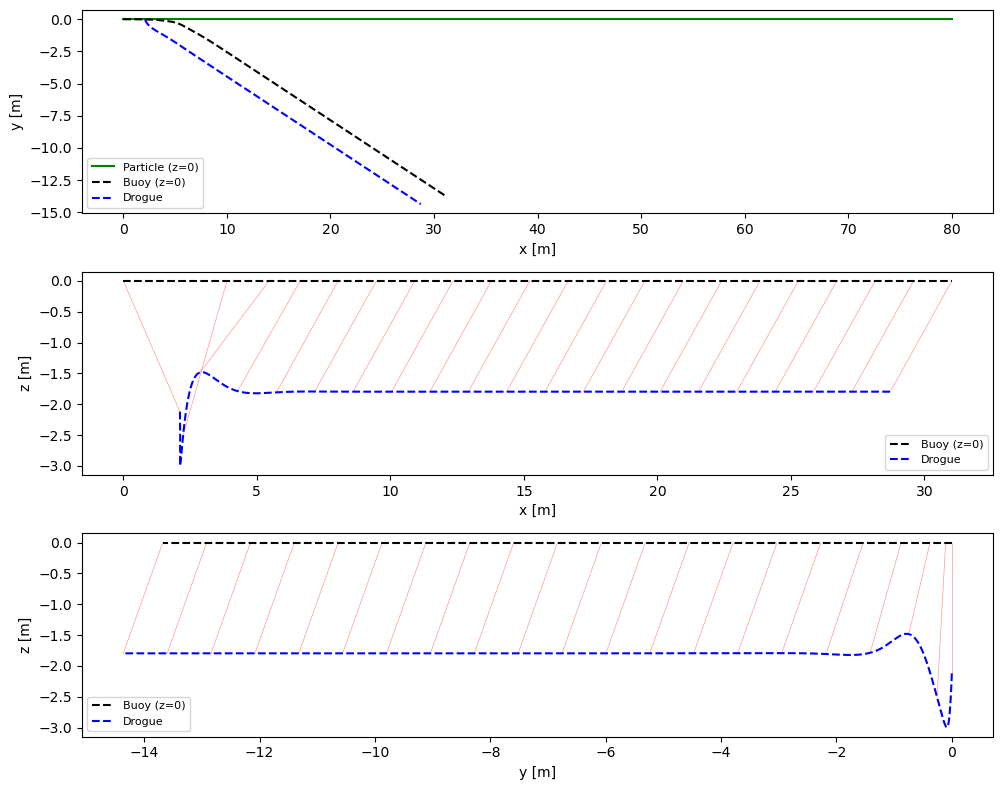

In [11]:
fig, (ax_xy, ax_xz, ax_yz) = plt.subplots(3, 1, figsize=(10, 8), sharey=False)

# x-y projection (top)
ax_xy.plot(x_particle, y_particle, "g-", label="Particle (z=0)")
ax_xy.plot(ds_fig.x, ds_fig.y, "k--", label="Buoy (z=0)")
ax_xy.plot(x_d, y_d, "b--", label="Drogue")
ax_xy.set_xlabel("x [m]")
ax_xy.set_ylabel("y [m]")
ax_xy.legend(fontsize=8)

# x-z projection (middle)
for i in range(0, len(t), pole_every):
    ax_xz.plot(
        [float(ds_fig.x[i]), float(x_d[i])], [0, float(z_d[i])], "r-", alpha=0.4, lw=0.5
    )
ax_xz.plot(ds_fig.x, np.zeros_like(ds_fig.x), "k--", label="Buoy (z=0)")
ax_xz.plot(x_d, z_d, "b--", label="Drogue")
ax_xz.set_xlabel("x [m]")
ax_xz.set_ylabel("z [m]")
ax_xz.legend(fontsize=8)

# y-z projection (bottom)
for i in range(0, len(t), pole_every):
    ax_yz.plot(
        [float(ds_fig.y[i]), float(y_d[i])], [0, float(z_d[i])], "r-", alpha=0.4, lw=0.5
    )
ax_yz.plot(ds_fig.y, np.zeros_like(ds_fig.y), "k--", label="Buoy (z=0)")
ax_yz.plot(y_d, z_d, "b--", label="Drogue")
ax_yz.set_xlabel("y [m]")
ax_yz.set_ylabel("z [m]")
ax_yz.legend(fontsize=8)

# share z range for the two side views
ax_yz.set_ylim(ax_xz.get_ylim())

fig.tight_layout()
fig.savefig("../manuscript/figures/example_in_sheared_flow_1.png", dpi=150)
plt.show()